In [1]:
import pandas as pd
import plotly.express as px

In [42]:
servicioAguaEntubada = pd.read_excel(
    '../data/ServicioAguaEntubada/d1_siscds03_01.xlsx',
    skiprows=2,
    header=0
)
servicioAguaEntubada=servicioAguaEntubada.drop(0)
# Si la primera columna se llama 'Unnamed: 0' o similar, renombrarla
if servicioAguaEntubada.columns[0] != 'Entidad':
    servicioAguaEntubada.rename(columns={servicioAguaEntubada.columns[0]: 'Entidad'}, inplace=True)
servicioAguaEntubada

,Entidad,1990,1995,2000,2005,2010,2015,2020
1,Aguascalientes,95.49,97.97,97.89,97.79,98.84,99.14,99.33
2,Baja California,79.76,86.75,91.94,93.84,95.87,97.13,97.68
3,Baja California Sur,89.37,90.86,92.53,87.69,92.56,92.70,94.14
4,Campeche,69.85,78.28,84.68,88.35,89.99,93.49,95.57
5,Coahuila,91.92,94.59,97.02,97.34,98.32,98.20,98.86
6,Colima,93.03,95.82,97.12,97.79,98.57,98.98,99.07
7,Chiapas,57.27,65.55,73.54,73.50,77.29,86.46,88.87
8,Chihuahua,87.57,91.79,93.07,92.86,94.57,95.73,98.13
9,Ciudad de México,96.13,97.74,97.85,97.58,97.67,98.58,98.65
10,Durango,84.60,89.58,91.65,90.91,93.87,96.67,97.50


Datos transformados:
               Entidad   Año  Porcentaje
0       Aguascalientes  1990       95.49
1      Baja California  1990       79.76
2  Baja California Sur  1990       89.37
3             Campeche  1990       69.85
4             Coahuila  1990       91.92

Años disponibles: [np.int64(1990), np.int64(1995), np.int64(2000), np.int64(2005), np.int64(2010), np.int64(2015), np.int64(2020)]
Entidades: 33


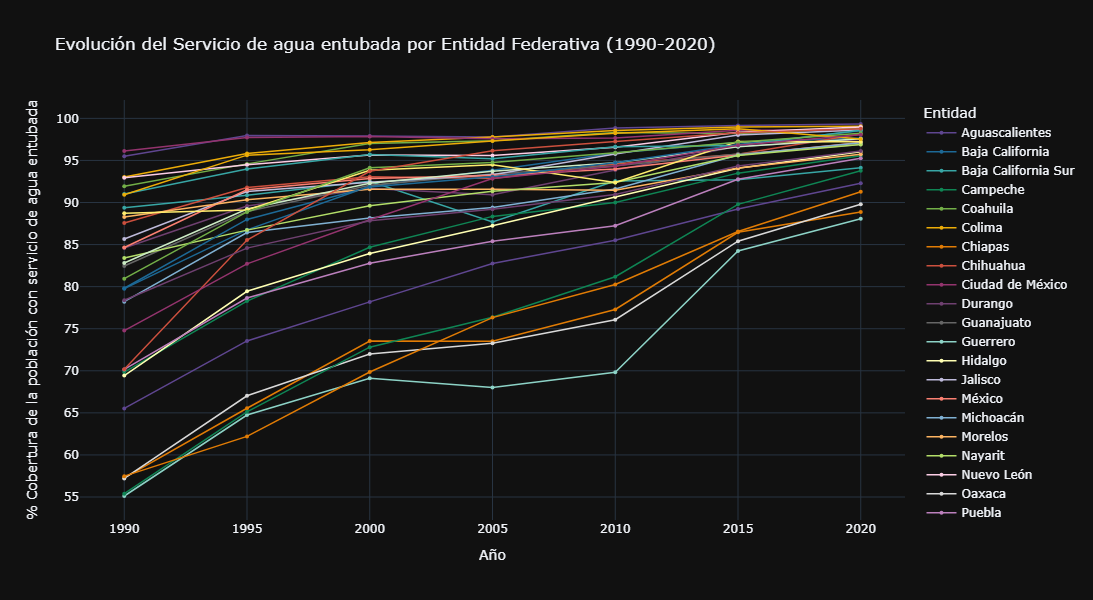

In [48]:
columna_entidad = servicioAguaEntubada.columns[0]  
colores = px.colors.qualitative.Prism + px.colors.qualitative.Set3
df_tidy = pd.melt(
    servicioAguaEntubada,  
    id_vars=[columna_entidad],
    var_name='Año', 
    value_name='Porcentaje'
)
df_tidy['Año'] = df_tidy['Año'].astype(int)

# Verificar que funcionó
print("Datos transformados:")
print(df_tidy.head())
print(f"\nAños disponibles: {sorted(df_tidy['Año'].unique())}")
print(f"Entidades: {df_tidy['Entidad'].nunique()}")

# Crear gráfico de líneas
fig = px.line(
    df_tidy, 
    x='Año', 
    y='Porcentaje', 
    color='Entidad',
    color_discrete_sequence=colores,
    title='Evolución del Servicio de agua entubada por Entidad Federativa (1990-2020)',
    labels={'Porcentaje': '% Cobertura de la población con servicio de agua entubada', 'Año': 'Año'},
    template='plotly_dark'
)

# Mejorar visualización
fig.update_traces(mode='lines+markers', marker=dict(size=4), line=dict(width=1.5))
fig.update_layout(
    height=600,
    hovermode='x unified',
    legend=dict(
        title='Entidad',
        orientation='v',
        yanchor='top',
        y=1,
        xanchor='left',
        x=1.02
    )
)

# Mostrar gráfica
fig.show()

# Guardar como HTML interactivo
fig.write_html('grafica_servicio_agua_entubada.html')

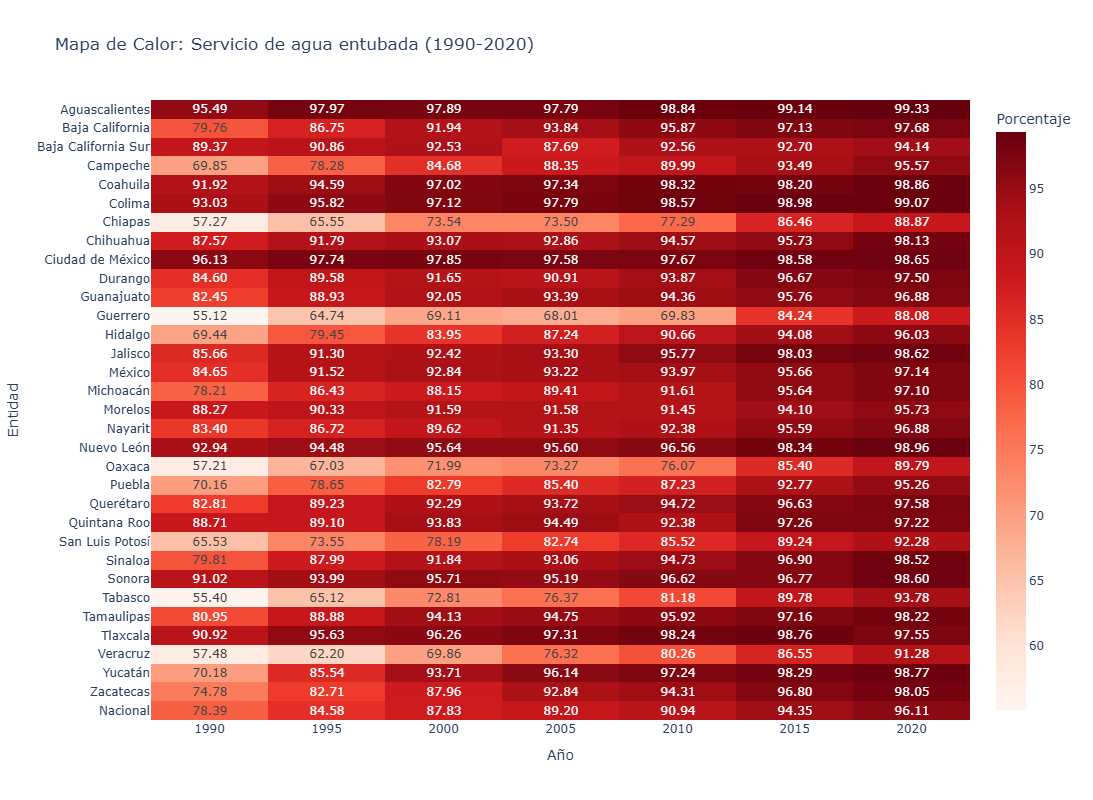

In [50]:
matriz = servicioAguaEntubada.set_index('Entidad')
fig = px.imshow(
    matriz,
    text_auto='.2f',
    aspect='auto',
    title='Mapa de Calor: Servicio de agua entubada (1990-2020)',
    labels=dict(x='Año', y='Entidad', color='Porcentaje'),
    color_continuous_scale='Reds',
    template='plotly_white'
)
fig.update_layout(height=800)
fig.write_html('mapa_calor_servicio_agua_entubada.html')
fig.show()